In [38]:
# conda activate anndata

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

In [22]:
psi_data = "tasic_2018_ALM_STAR_SyntheticDataset1_25pcntCells_100SD_200samples_SJ_pseudobulk_min_observed0.05_PSI"

In [23]:
corr_df = pd.read_csv(f"data/{psi_data}_exon_corr.csv", index_col=0)

### Prep PSI data

In [7]:
# Load PSI data
sdata = ad.read_h5ad("data/tasic_2018_ALM_STAR_SJ_counts_annotated_PSI.hd5")

In [8]:
sdata.shape

(9573, 14924)

In [9]:
# Load cell metadata and latent space
adata = ad.read_h5ad("data/tasic_2018_ALM_STAR_model/tasic_2018_ALM_STAR_gene_counts_scVI.h5ad")

In [10]:
sum(adata.obs_names == sdata.obs_names)

9573

In [11]:
sc.pp.neighbors(adata, use_rep="scVI")
sc.tl.umap(adata, min_dist=0.2)

/mnt/lareaulab/reliscu/anaconda3/envs/anndata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
corr_df

,Gene,Astro,Endo,Macrophage,Oligo,SMC,VLMC,L5_IT,Pvalb,Lamp5,L2_3_IT,Sst,Vip,NP,L6_IT,Sncg,L5_PT,L6_CT,Serpinf1,L6b
ENSMUSG00000025902_ProteinCoding_1,Sox17,-0.114326,0.049379,0.022360,0.013979,0.090492,-0.004305,-0.132091,0.152995,-0.047372,-0.080808,-0.017876,-0.018098,-0.050932,0.006227,0.036393,-0.040675,0.020245,0.130366,-0.006883
ENSMUSG00000025902_ProteinCoding_2,Sox17,-0.115290,0.049829,0.022127,0.015273,0.090004,-0.005338,-0.133277,0.152357,-0.047256,-0.080553,-0.017309,-0.017402,-0.050683,0.005794,0.035532,-0.039364,0.020977,0.130200,-0.006032
ENSMUSG00000025902_ProteinCoding_3,Sox17,-0.032828,0.479492,-0.053066,0.014345,0.066446,-0.035713,-0.000755,-0.019018,0.071431,-0.024103,-0.092211,-0.011788,-0.115992,-0.076207,-0.052042,-0.004976,0.019643,-0.093341,-0.005983
ENSMUSG00000025902_ProteinCoding_4,Sox17,-0.025486,0.479089,-0.061437,0.005103,0.081521,-0.040819,-0.005633,-0.003598,0.073075,-0.036491,-0.088909,-0.031221,-0.112138,-0.081132,-0.068777,0.014958,0.029161,-0.108554,-0.011732
ENSMUSG00000033845_ProteinCoding_1,Mrpl15,0.195661,-0.282692,0.030932,-0.273637,0.037326,-0.256692,0.173686,-0.182738,0.123795,0.085133,0.002736,-0.036843,0.112317,0.097253,0.119065,0.101205,-0.084165,0.085491,-0.005052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000068457_ProteinCoding_1,Uty,0.147867,0.156777,0.031213,0.515713,-0.002625,0.141368,-0.401120,0.007707,0.005236,-0.218246,0.035703,0.131024,-0.042982,-0.211672,-0.019964,-0.010791,-0.163920,0.161350,-0.103967
ENSMUSG00000068457_ProteinCoding_2,Uty,0.064539,-0.034729,0.121450,-0.616011,0.031176,0.155644,0.067683,-0.073084,0.109666,0.130871,-0.116777,0.009405,-0.001151,0.034530,0.103079,0.173322,0.044038,-0.022722,0.015885
ENSMUSG00000068457_NMD_3,Uty,-0.055199,0.039025,-0.136522,0.113827,-0.073862,-0.046275,0.053527,-0.098334,0.162085,0.041747,-0.127419,-0.037009,0.000334,0.172639,0.002791,-0.048420,0.008141,-0.001285,-0.063003
ENSMUSG00000068457_NMD_4,Uty,0.070134,0.025891,-0.120202,-0.127887,0.005823,-0.088600,0.052272,-0.016510,0.009341,-0.044227,-0.018020,-0.061154,0.012055,0.005653,-0.014776,0.009151,0.180024,-0.033071,0.052033


### Visualize

In [35]:
ctypes

Index(['Astro', 'Endo', 'Macrophage', 'Oligo', 'SMC', 'VLMC', 'L5_IT', 'Pvalb',
       'Lamp5', 'L2_3_IT', 'Sst', 'Vip', 'NP', 'L6_IT', 'Sncg', 'L5_PT',
       'L6_CT', 'Serpinf1', 'L6b'],
      dtype='object')

In [27]:
ctypes = corr_df.columns[1:]
gene_names_df = corr_df['Gene']

In [61]:
i = np.where(ctypes == "Oligo")[0][0]
ctype = ctypes[i]
print(ctype)

# --------

corr_df = corr_df.sort_values(ctype, ascending=False)
corr_df.head(10)

Oligo


,Gene,Astro,Endo,Macrophage,Oligo,SMC,VLMC,L5_IT,Pvalb,Lamp5,L2_3_IT,Sst,Vip,NP,L6_IT,Sncg,L5_PT,L6_CT,Serpinf1,L6b
ENSMUSG00000024044_ProteinCoding_6,Epb41l3,-0.051971,-0.062208,-0.085251,0.978834,0.012593,-0.042940,-0.215995,-0.151184,-0.031079,-0.144140,-0.103300,-0.083308,0.068636,-0.023857,-0.124141,-0.054957,-0.004944,-0.022606,-0.014058
ENSMUSG00000028399_ProteinCoding_1,Ptprd,0.018548,-0.083371,-0.067551,0.969662,-0.007459,-0.033415,-0.240368,-0.131489,-0.052976,-0.126070,-0.071451,-0.105993,0.054267,-0.025780,-0.149222,-0.040658,-0.018142,-0.028779,-0.049787
ENSMUSG00000033904_ProteinCoding_1,Ccp110,-0.061272,-0.001008,-0.086968,0.969134,-0.004874,-0.078531,-0.229860,-0.144827,-0.045561,-0.141047,-0.090112,-0.048367,0.051674,-0.013121,-0.114074,-0.053911,-0.020960,-0.029816,0.002613
ENSMUSG00000026442_ProteinCoding_2,Nfasc,0.046196,-0.035808,-0.055134,0.958903,-0.017316,-0.013086,-0.250022,-0.154225,-0.029237,-0.152170,-0.096508,-0.077835,0.093444,-0.055419,-0.108372,-0.091585,-0.027580,-0.005892,-0.053870
ENSMUSG00000022044_ProteinCoding_3,Stmn4,-0.040066,-0.087150,-0.111211,0.957205,-0.005198,-0.021152,-0.337496,-0.042049,0.007480,-0.225475,-0.008459,-0.021020,0.048051,-0.145162,-0.006497,-0.031391,-0.060353,0.063615,-0.011609
ENSMUSG00000032366_ProteinCoding_1,Tpm1,0.072494,-0.051283,-0.099359,0.950594,0.078703,0.022445,-0.314018,-0.094286,-0.024062,-0.324697,-0.065677,-0.053616,0.120261,-0.088696,-0.080812,-0.132610,-0.032524,0.017141,-0.027063
ENSMUSG00000038608_ProteinCoding_3,Dock10,-0.041820,-0.092498,-0.175407,0.949868,-0.081727,-0.044470,-0.190346,-0.096684,-0.045845,-0.149930,-0.038995,-0.064409,0.074426,0.001177,-0.094712,-0.087138,0.009009,-0.017589,-0.011287
ENSMUSG00000021969_other_1,Zdhhc20,0.054216,-0.004316,-0.107648,0.947312,-0.004315,-0.070028,-0.217928,-0.120027,-0.009952,-0.121189,-0.088679,-0.081795,0.058498,-0.043291,-0.149122,-0.066922,-0.057231,-0.034172,-0.053400
ENSMUSG00000024924_ProteinCoding_3,Vldlr,0.118263,-0.029305,-0.079606,0.943808,-0.043902,-0.053423,-0.199176,-0.130688,-0.124038,-0.149659,-0.083601,-0.081876,0.094318,-0.037473,-0.166481,-0.072670,-0.015090,-0.069684,-0.019971
ENSMUSG00000069601_ProteinCoding_3,Ank3,-0.052253,0.002407,-0.061948,0.935595,0.057609,-0.022173,-0.231690,-0.157318,-0.022428,-0.145728,-0.107934,-0.062659,0.028615,-0.034854,-0.121232,-0.038768,-0.046126,-0.018868,-0.012750


In [62]:
top_exons_df = corr_df[ctype][1:10]
top_exons = top_exons_df.index.tolist()
top_genes = gene_names_df.loc[top_exons].tolist()

mask = sdata.var_names.isin(top_exons)
sdata_sub = sdata[:, mask]
psi_df = pd.DataFrame(
    sdata_sub.X, index=sdata_sub.obs_names, columns=sdata_sub.var_names
)

adata_temp = adata.copy()
adata_temp.obs = adata_temp.obs.join(psi_df)

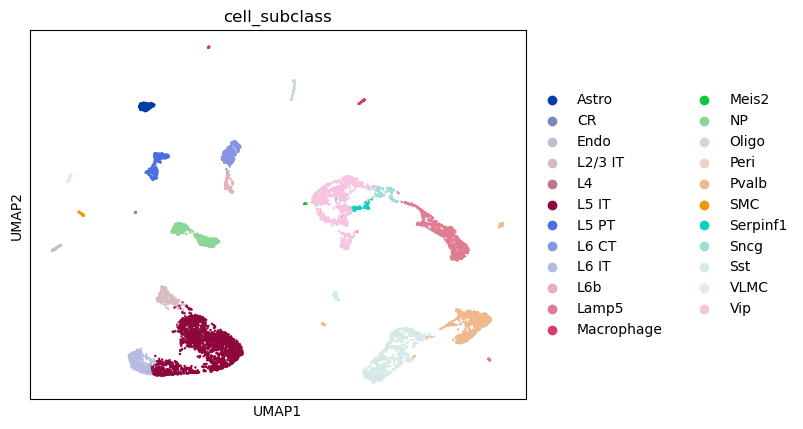

In [63]:
sc.pl.umap(adata_temp, color=["cell_subclass"])

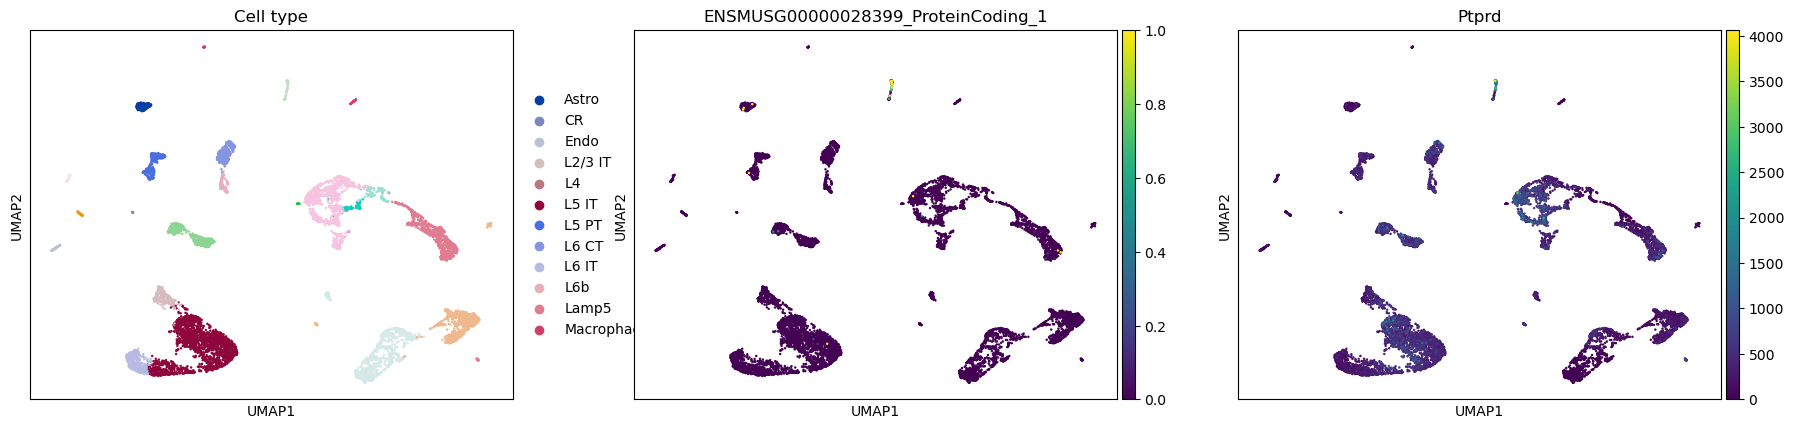

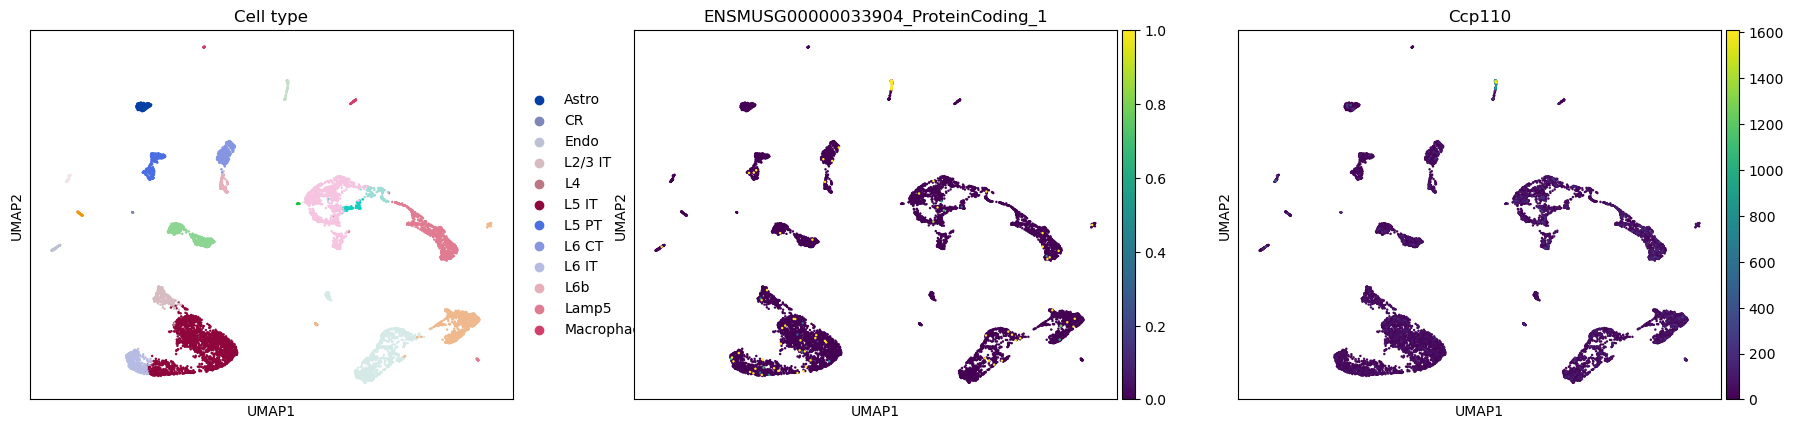

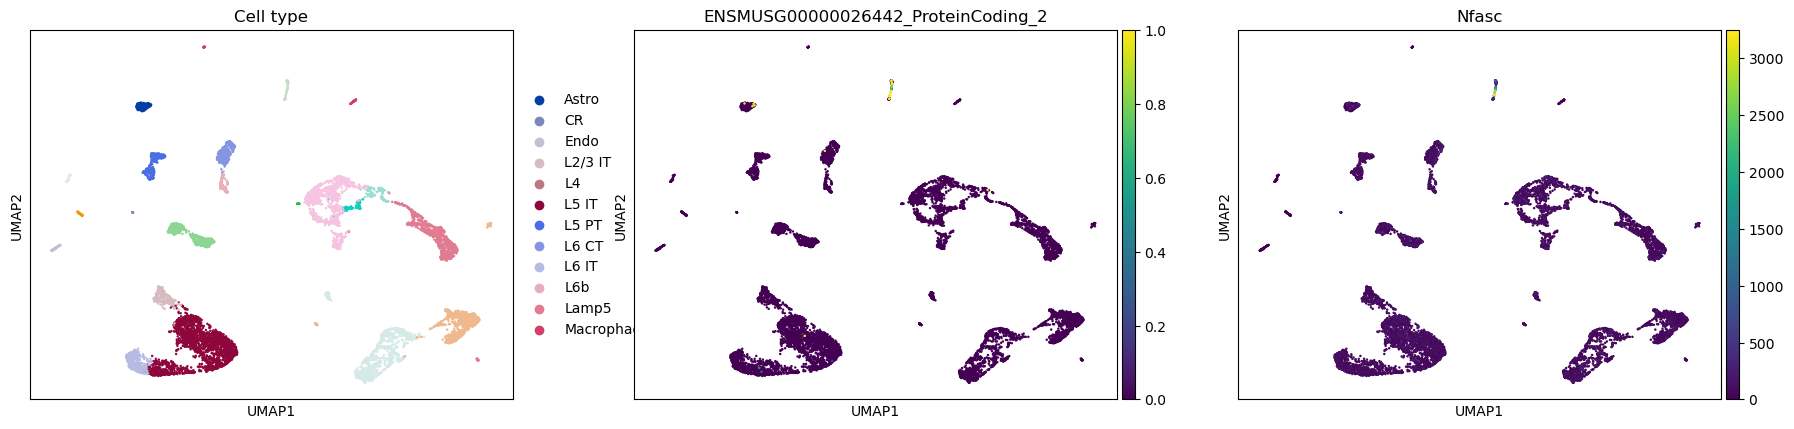

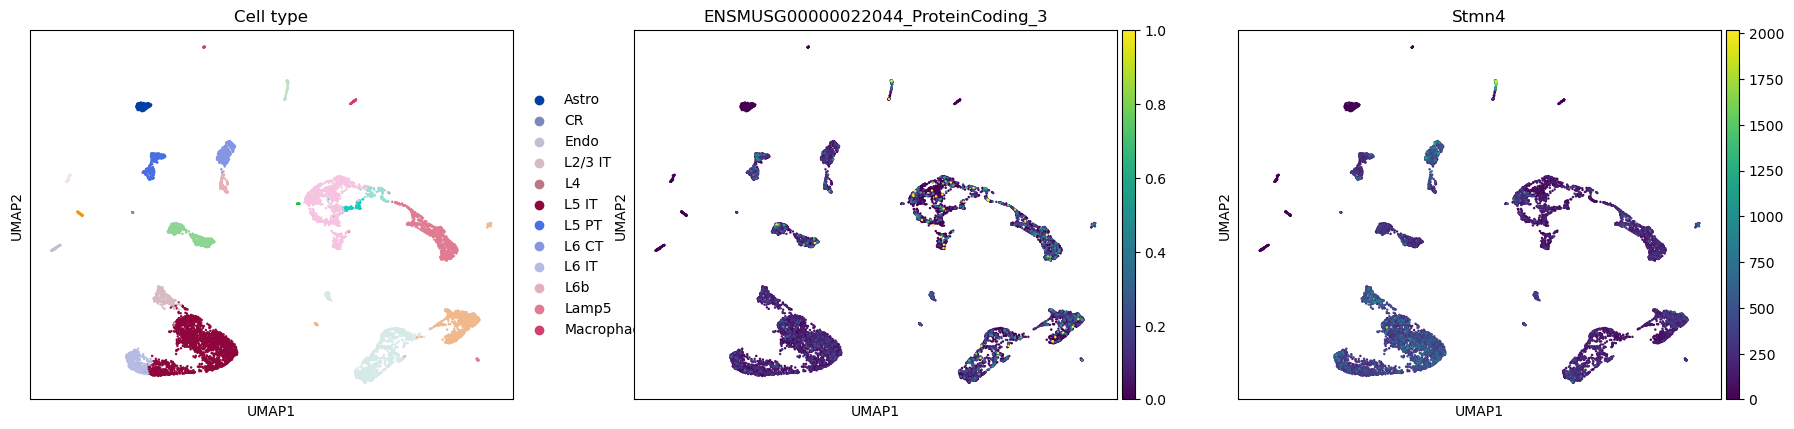

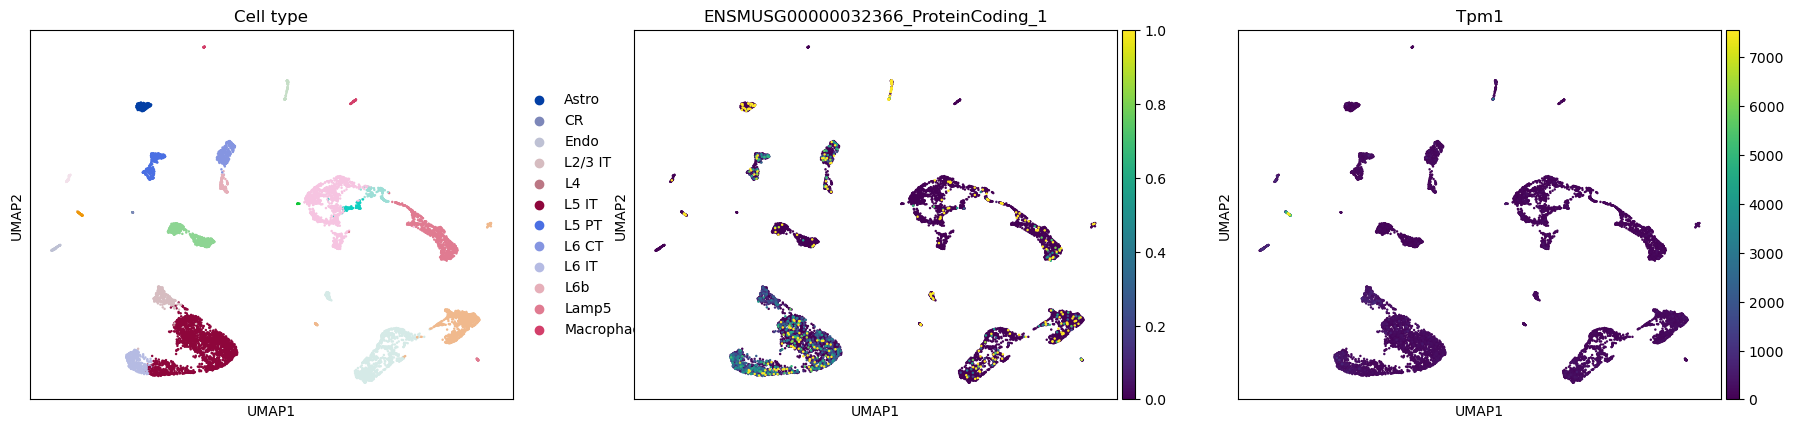

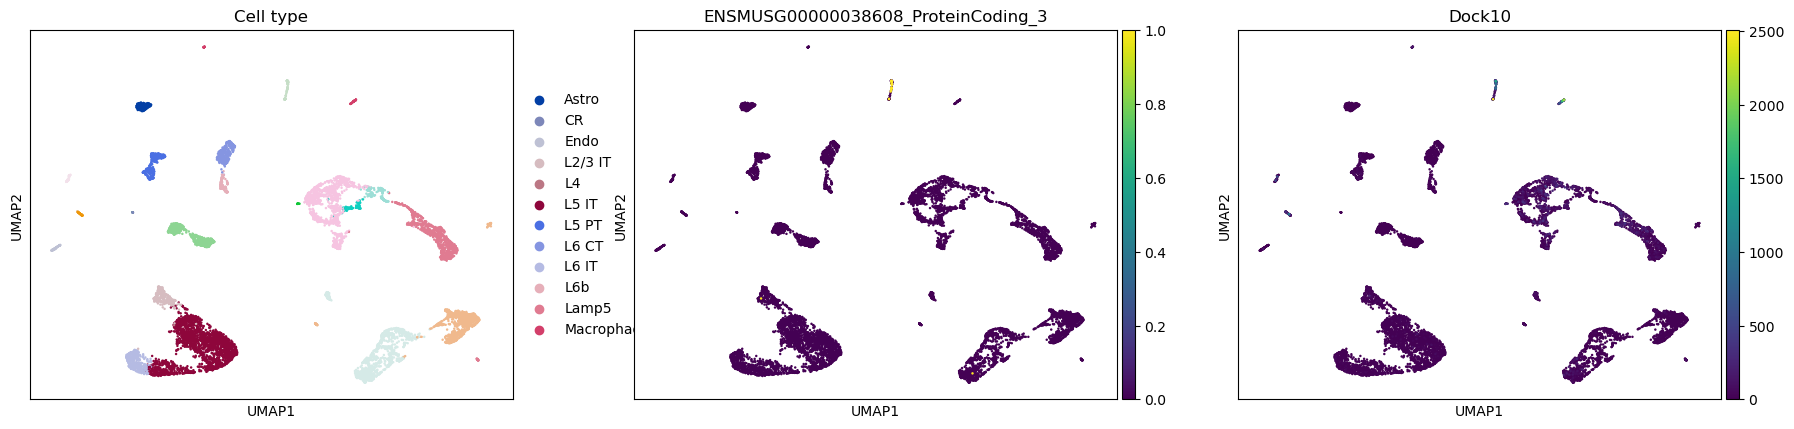

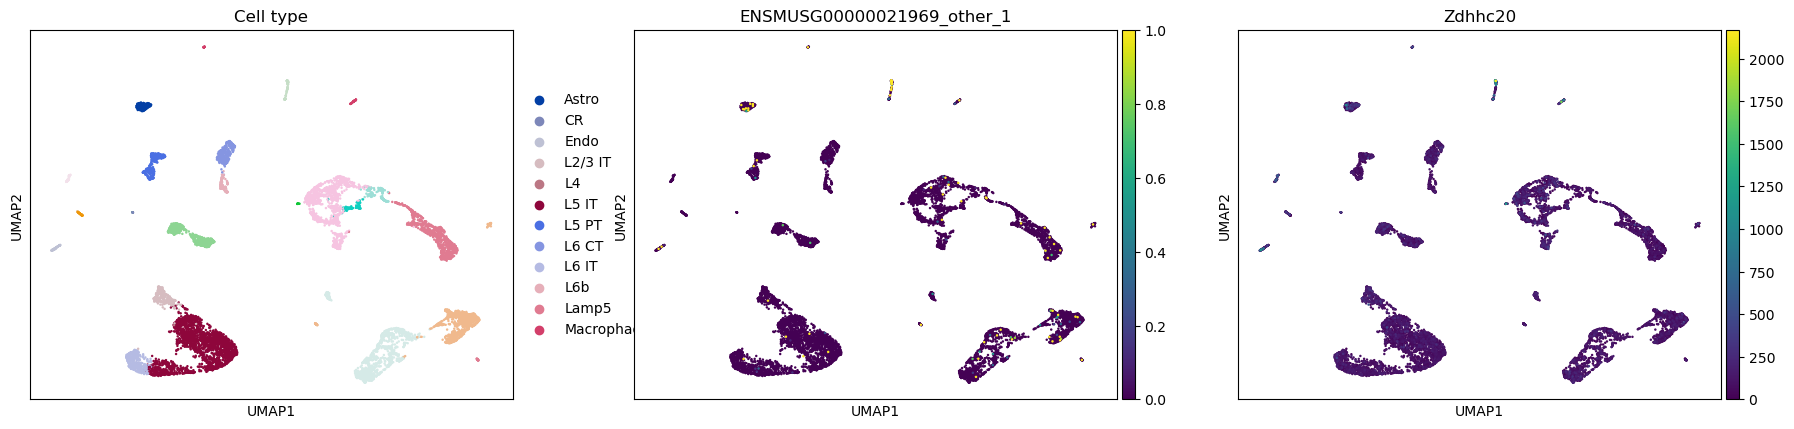

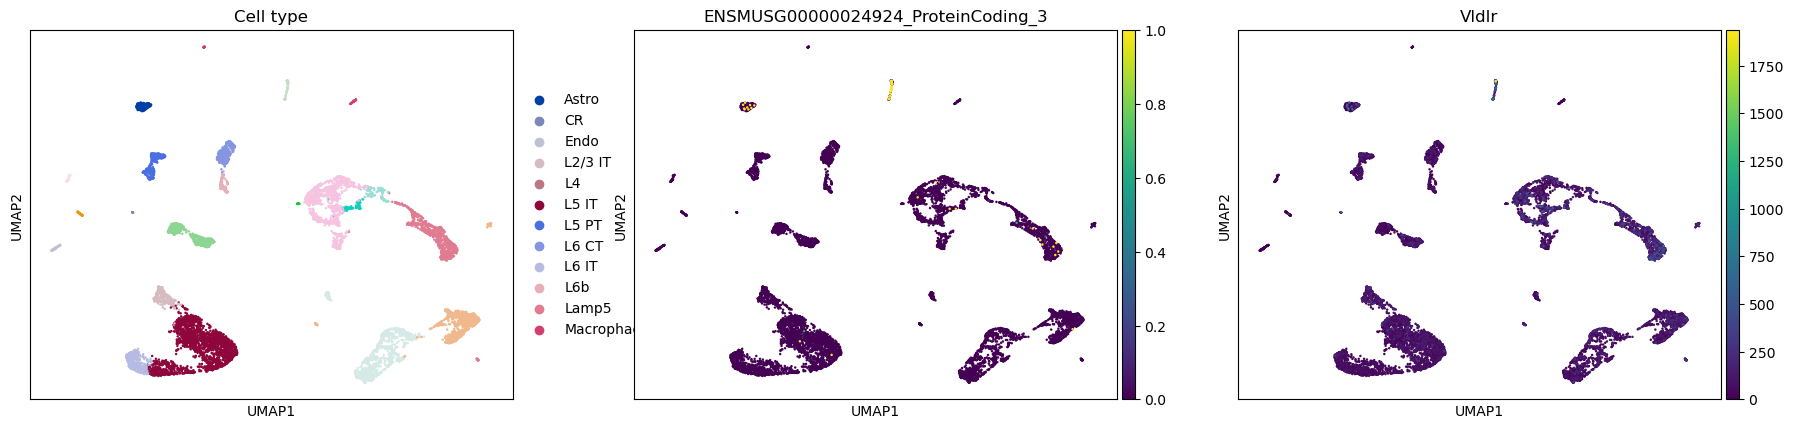

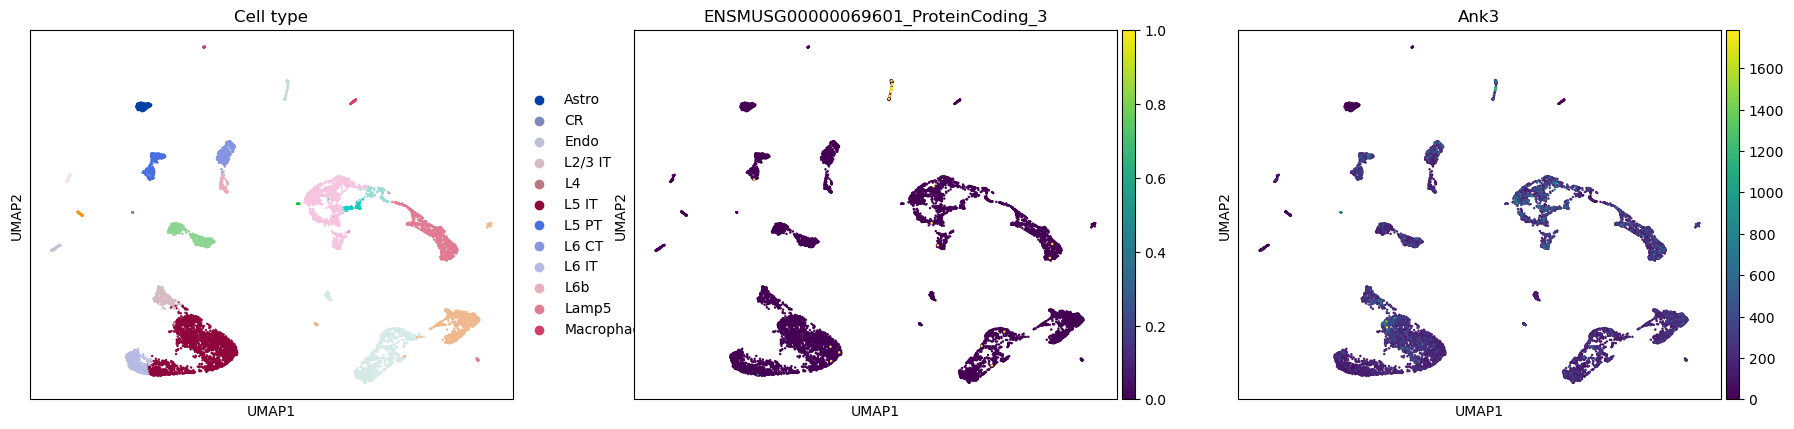

In [64]:
for idx, value in enumerate(top_exons):
    sc.pl.umap(adata_temp, color=["cell_subclass", value, top_genes[idx]], title=["Cell type", value, top_genes[idx]], use_raw=True)